In [18]:
# ============================================================
# Automated Naranjo Causality Assessment with LLMs
# Bayesian Optimization
# ============================================================

# -------------------------
# Library imports
# -------------------------
%pip install pymysql sqlalchemy pandas gpytorch botorch sentence-transformers openpyxl openai
# !pip install openai -q

import os
import re
import json
import time
from datetime import datetime
from pathlib import Path
from typing import Dict, Tuple, Optional, List
from tqdm import tqdm

import requests
from bs4 import BeautifulSoup
from sqlalchemy import create_engine, text

import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.stats import entropy as scipy_entropy
from sentence_transformers import SentenceTransformer

import torch
import gpytorch
import botorch
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

import openai
from openai import OpenAI
#from google.colab import userdata


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openai]━━━━ 1/2 [openai]
Note: you may need to restart the kernel to use updated packages.


# Should probably use these files, but I do not have them:

In [6]:
# --- Load files ---
# Adjust paths as needed
assessed = pd.read_excel('Cases_assessed.xlsx')
narratives = pd.read_excel('Cases_narrative.xlsx')

# --- Deduplicate: keep one row per CASE_ID ---
assessed_unique = assessed.drop_duplicates(subset='CASE_ID', keep='first')

# --- Merge narrative in ---
merged = assessed_unique.merge(
    narratives,
    left_on='CASE_ID',
    right_on='primaryid',
    how='left'
)

# --- Save result ---
merged.to_excel('cases_with_narratives.xlsx', index=False)

print(f"Assessed rows (before dedup): {len(assessed)}")
print(f"Unique CASE_IDs: {len(assessed_unique)}")
print(f"Merged rows: {len(merged)}")
print(f"Narrative match rate: {merged['primaryid'].notna().sum()}/{len(merged)}")

Assessed rows (before dedup): 5534
Unique CASE_IDs: 723
Merged rows: 723
Narrative match rate: 723/723


In [8]:
df = pd.read_excel("cases_with_narratives.xlsx")

In [9]:
df

,id,CASE_ID,PT,Drug_Name,Q1_Score,Q1_Reasoning,Q2_Score,Q2_Reasoning,Q3_Score,Q3_Reasoning,...,wt_cod,rept_dt,to_mfr,occp_cod,reporter_country,occr_country,pt,indi_pt,narrative,narrative_clean
0,1,100294532,Metastases to liver,LETROZOLE,0,not found in the SmPC (link: https://www.produ...,0,the case does not provide any infomation on th...,0,the case does not provide any information on d...,...,NaN,20250326,NaN,HP,IT,IT,Metastases to liver ; Metastases to lymph node...,Breast cancer metastatic ; Breast cancer metas...,Case ID: 100294532 \n Case Version: 2 \n FDA C...,Case ID: 100294532 \n Case Version: 2 \n FDA C...
1,37,100496573,Fall,LUMIZYME,0,not found in the SmPC (link: https://www.ema.e...,0,the case does not provide any infomation on th...,0,the case does not provide any information on d...,...,KG,20250307,NaN,MD,US,US,Fall ; Arthralgia ; C-reactive protein increas...,Glycogen storage disease type II ; Glycogen st...,Case ID: 100496573 \n Case Version: 3 \n FDA C...,Case ID: 100496573 \n Case Version: 3 \n FDA C...
2,67,1005762122,Paraesthesia,XOLAIR,1,found in the SmPC as paraesthesia (link: https...,0,the case does not provide any infomation on th...,0,the case does not provide any information on d...,...,KG,20250110,NaN,CN,CA,CA,Paraesthesia ; Joint swelling ; Nasopharyngiti...,Asthma ; Asthma ; ; ; ; ; ; ; ; ; ; ...,Case ID: 1005762122 \n Case Version: 22 \n FDA...,Case ID: 1005762122 \n Case Version: 22 \n FDA...
3,367,1016133064,Blood pressure systolic increased,ACTEMRA,1,found in the SmPC as high blood pressure (link...,0,the case does not provide any infomation on th...,0,the case does not provide any information on d...,...,KG,20250318,NaN,HP,CA,CA,Blood pressure systolic increased ; Off label ...,Rheumatoid arthritis ; Rheumatoid arthritis ; ...,Case ID: 1016133064 \n Case Version: 64 \n FDA...,Case ID: 1016133064 \n Case Version: 64 \n FDA...
4,592,101815233,Death,FLUCLOXACILLIN,0,not found in the SmPC (link: https://assets.hp...,0,the case does not provide any infomation on th...,0,the case does not provide any information on d...,...,KG,20250605,NaN,PH,GB,GB,Death ; Off label use ; Cellulitis ; Infection...,Medication dilution ; Medication dilution ; Ce...,Case ID: 101815233 \n Case Version: 3 \n FDA C...,Case ID: 101815233 \n Case Version: 3 \n FDA C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,8856,151654974,Foetal exposure during pregnancy,RAMIPRIL,0,not found in the FDA-label (link: https://dail...,0,the case does not provide information on thera...,0,the case does not provide any information on d...,...,KG,20250505,NaN,MD,DE,DE,Foetal exposure during pregnancy ; Fallot's te...,Product used for unknown indication ; ; Produ...,Case ID: 151654974 \n Case Version: 4 \n FDA C...,Case ID: 151654974 \n Case Version: 4 \n FDA C...
719,8862,151671392,Drug hypersensitivity,PREGABALIN,1,found in the FDA-label as hypersensitivity (li...,0,the case does not provide information on thera...,0,the case does not provide any information on d...,...,NaN,20250207,NaN,HP,US,US,Drug hypersensitivity ; Swelling,Product used for unknown indication ; Product ...,Case ID: 151671392 \n Case Version: 2 \n FDA C...,Case ID: 151671392 \n Case Version: 2 \n FDA C...
720,8870,152291959,Intestinal obstruction,VEDOLIZUMAB,0,not found in the FDA-label (link: https://dail...,0,the case does not provide information on thera...,0,the case does not provide any information on d...,...,NaN,20250325,NaN,NaN,CA,CA,Intestinal obstruction ; Intestinal fistula ; ...,Crohn's disease ; Crohn's disease ; Crohn's di...,Case ID: 152291959 \n Case Version: 9 \n FDA C...,Case ID: 152291959 \n Case Version: 9 \n FDA C...
721,8878,1510415521,Malignant neoplasm progression,PALBOCICLIB,0,not found in the FDA-label (link: https://dail...,0,the case does not provide information on thera...,0,the case does not provide any information on d...,...,NaN,20250612,NaN,CN,IN,IN,Malignant neoplasm progression ; Lower res

# Starting from off_the_shelf.xlsx file, which I have

In [ ]:
# Load the data from the off the shelf file
df = pd.read_excel("/naranjo_results_batch.xlsx")
df = df.drop_duplicates(subset=['CASE_ID'], keep='first')
# Select the columns we need to run the model only
df = df[
    ["CASE_ID", "Drug_Name", "PT", "narrative_clean",] +
    list(df.columns[pd.Series(df.columns).str.endswith('_Reasoning')]) +
    list(df.columns[pd.Series(df.columns).str.endswith('_Score')])
  ]
print(f"📊 Original number of rows: {len(df)}")
df.head()

📊 Original number of rows: 723


,CASE_ID,Drug_Name,PT,narrative_clean,Q1_Reasoning,Q2_Reasoning,Q3_Reasoning,Q4_Reasoning,Q5_Reasoning,Q6_Reasoning,...,Q2_Score,Q3_Score,Q4_Score,Q5_Score,Q6_Score,Q7_Score,Q8_Score,Q9_Score,Q10_Score,Result_Final_Score
0,100294532,LETROZOLE,Metastases to liver,Case ID: 100294532 \n Case Version: 2 \n FDA C...,not found in the SmPC (link: https://www.produ...,the case does not provide any infomation on th...,the case does not provide any information on d...,the case does not provide any information on r...,"from the information provided by the case, the...",the case does not provide any information on p...,...,0,0,0,-1,0,0,0,0,1,0
1,100496573,LUMIZYME,Fall,Case ID: 100496573 \n Case Version: 3 \n FDA C...,not found in the SmPC (link: https://www.ema.e...,the case does not provide any infomation on th...,the case does not provide any information on d...,the case does not provide any information on r...,"the patient suffers from Pompe disease, for wh...",the case does not provide any information on p...,...,0,0,0,-1,0,0,0,0,1,0
2,1005762122,XOLAIR,Paraesthesia,Case ID: 1005762122 \n Case Version: 22 \n FDA...,found in the SmPC as paraesthesia (link: https...,the case does not provide any infomation on th...,the case does not provide any information on d...,the case does not provide any information on r...,paraesthesia is a known symptom of both parkin...,the case does not provide any information on p...,...,0,0,0,-1,0,0,0,0,1,1
3,1016133064,ACTEMRA,Blood pressure systolic increased,Case ID: 1016133064 \n Case Version: 64 \n FDA...,found in the SmPC as high blood pressure (link...,the case does not provide any infomation on th...,the case does not provide any information on d...,the case does not provide any information on r...,the patient is 69 years old. hypertension is c...,the case does not provide any information on p...,...,0,0,0,-1,0,0,0,0,1,1
4,101815233,FLUCLOXACILLIN,Death,Case ID: 101815233 \n Case Version: 3 \n FDA C...,not found in the SmPC (link: https://assets.hp...,the case does not provide any infomation on th...,the case does not provide any information on d...,the case does not provide any information on r...,the patient suffered from anaplastic large cel...,the case does not provide any information on p...,...,0,0,0,-1,0,0,0,0,1,0


In [10]:
# ============================================================
# 🧭 Naranjo prompts
# ============================================================
PROMPTS = {
    2: """Q2: Did the adverse event appear after the suspected drug was administered?
Score: 2 for Yes, -1 for No, 0 for Do not know.
Reasoning: Given the reported timeline and the known route of administration, consider the likelihood that these reactions were temporally related to suspected drug administration.
Analyze if the timing is consistent with expected adverse reactions and whether the adverse event appeared immediately, shortly after, or with a delayed onset.""",

    3: """Q3: Did the adverse event improve when the suspected drug was discontinued, or a specific antagonist was administered?
Score: 1 for Yes, 0 for No/Do not know.
Reasoning: Search for dechallenge data in the case prompt. Discuss whether improvement upon discontinuation would have provided stronger causality evidence.
If no dechallenge data is available, explain why the absence affects the score.""",

    4: """Q4: Did the adverse event reappear when the suspected drug was readministered?
Score: 2 for Yes, -1 for No, 0 for Do not know.
Reasoning: Search for rechallenge data in the case provided. If marked as "not available", explain how the absence affects the analysis. Would rechallenge data have strengthened the score?""",

    5: """Q5: Are there alternative causes, based only on the information explicitly provided in the case, that could on their own cause the adverse event?
Score: -1 for Yes, 2 for No.
Reasoning: Consider all alternative causes that are supported by the case narrative, such as concomitant medications, underlying diseases, infections, procedures, or other documented clinical factors.
If none are identified, note this as supporting causality. If alternative causes are identified, explain how they affect the likelihood that the suspected drug caused the event.""",

    6: """Q6: Did the adverse event reappear when a placebo was given?
Score: -1 for Yes, 1 for No, 0 for Do not know.
Reasoning: Search if placebo data is available in the case provided. If not found, reflect on how the absence of a placebo test impacts causality determination.
Consider the limitations of assessing causality without this control measure.""",

    7: """Q7: Was the suspected drug detected in any body fluid in toxic concentrations?
This question applies specifically to dose-dependent adverse reactions when blood, urine, tissue or other specimen concentrations of the medicine are available.
Score: 1 for Yes, 0 for No/Do not know.
Reasoning: Search for toxicology data in the case provided. If not found, discuss how the lack of such data affects the causality score. If this information had been available, it might have provided more clarity on the association with the suspected drug.""",

    8: """Q8: Was the adverse event more severe when the dose was increased or less severe when the dose was decreased?
Score: 1 for Yes, 0 for No/Do not know.
Reasoning: Search in the case provided if the drug has been administered in different doses. If different doses were used, analyze whether there is any indication that symptoms varied with dose changes, even if data on dose-specific reactions is limited.""",

    9: """Q9: Did the patient have a similar adverse event to the same or similar drugs in any previous exposure?
Score: 1 for Yes, 0 for No/Do not know.
Reasoning: Consider any history of similar reactions to the suspected drug or related medications, and discuss how this would influence causality if relevant prior reactions existed.
Consider whether the patient had prior adverse events to the same drug previously or to a drug in the same pharmacological class. If a positive history exists, this strengthens causality. If no history is available, discuss how this affects the overall assessment.""",

    10: """Q10: Was the adverse event confirmed by any objective evidence?
Score: 1 for Yes, 0 for No/Do not know.
Reasoning: Determine whether the reported adverse event represents a medical sign—which by nature requires objective validation through diagnostic tests, imaging, or clinical examination—or a symptom that relies solely on patient report (e.g., headache or fatigue).
If the adverse event represents a medical sign, assume that a qualified healthcare professional has performed the necessary diagnostic evaluations, even if the case narrative does not explicitly mention them, and score accordingly as 'Yes'.
If the event is purely subjective and cannot be objectively verified, score 0.""",
}

In [12]:
# ============================================================
# 🤖 Calculate similarity score (with Anisotropy Correction)
# ============================================================
from sklearn.decomposition import PCA
import numpy as np

# 1. Load embedding model
encoder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

# 2. Build a representative corpus to learn the embedding space distribution
print("Fitting PCA for Anisotropy Correction...")
corpus_texts = []
# Grab all the expert reasonings from Q2 to Q10 to form a medical domain corpus
for q in range(2, 11):
    corpus_texts.extend(df[f'Q{q}_Reasoning'].dropna().tolist())

# Generate embeddings for the corpus (this might take a few seconds)
corpus_embeddings = encoder.encode(corpus_texts, show_progress_bar=True)

# Fit the Whitening transformation
pca_whitener = PCA(whiten=True)
pca_whitener.fit(corpus_embeddings)
print("PCA Whitening fitted successfully!")

# 3. Updated similarity function using the fitted PCA
def similarity_reasoning(corpus_human, corpus_ai, encoder, pca_model):
    # Encode the texts into raw embeddings
    human_emb_raw = encoder.encode(corpus_human)
    ai_emb_raw = encoder.encode(corpus_ai)
    
    # Apply the whitening transformation to fix anisotropy
    human_emb = pca_model.transform(human_emb_raw)
    ai_emb = pca_model.transform(ai_emb_raw)
    
    # Calculate similarity between each human and ai reasoning
    similarity = []
    for i in range(0, len(ai_emb)):
        # standard cosine similarity on the whitened vectors
        sim = np.dot(ai_emb[i], human_emb[i]) / (np.linalg.norm(human_emb[i]) * np.linalg.norm(ai_emb[i]))
        similarity.append(sim)
        
    return similarity

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fitting PCA for Anisotropy Correction...


Batches:   0%|          | 0/204 [00:00<?, ?it/s]

PCA Whitening fitted successfully!


# Check the Anistropy Plot

### What to look for when you run this cell:

1. The Heatmap: Look at the top-right or bottom-left quadrants (where Q2 is compared against Q10). Since the text for Question 2 and Question 10 discuss different clinical data, a perfect semantic space would score them near 0.0. If you see them glowing warm/red (e.g., 0.70 or 0.80), you have explicitly proven that the raw cosine metric is failing to distinguish distinct medical topics.

2. The PCA Projection: Look at where the red and blue dots are clustered compared to the black X at the Origin (0,0). If they are heavily shifted into one specific quadrant of the graph rather than surrounding the origin, you are visually observing the anisotropic "cone", justifying your use of the PCA(whiten=True) fix inside the execution loop.

Generating embeddings for visualization...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

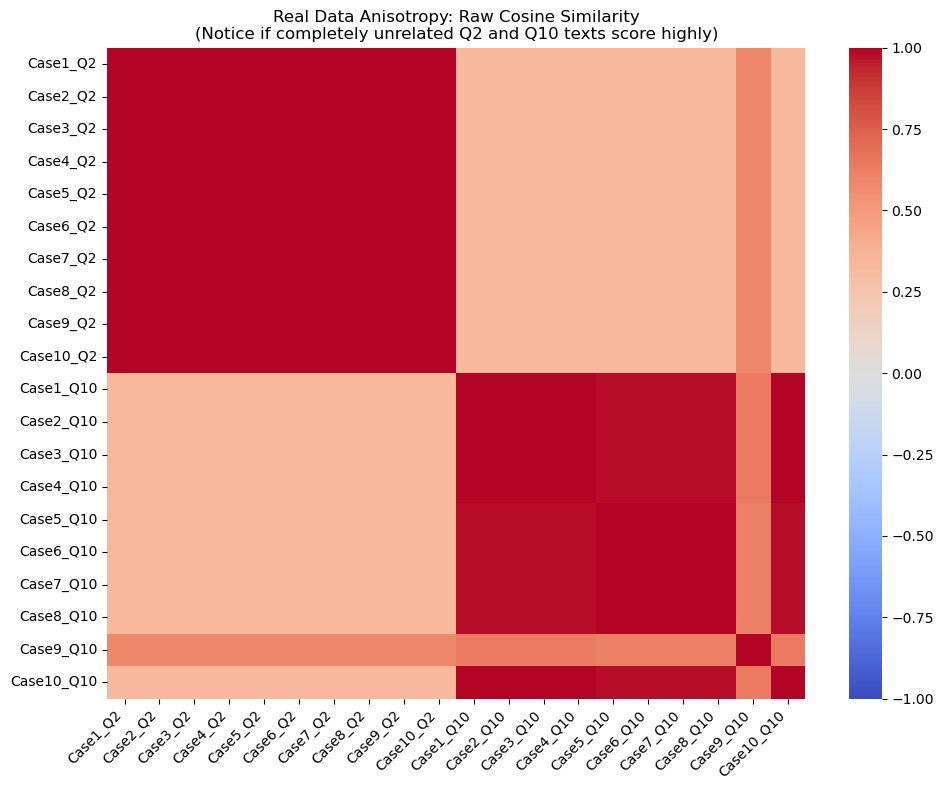

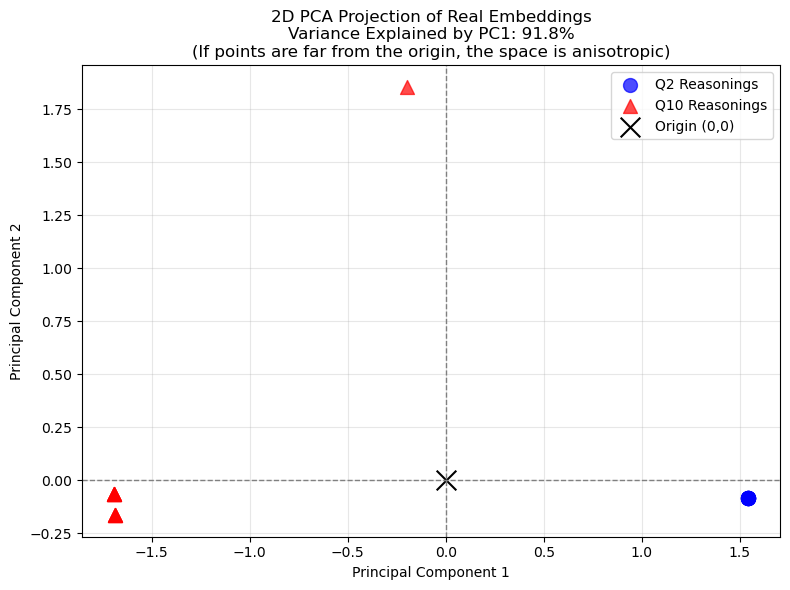

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# ============================================================
# 📊 Diagnostic: Visualize Anisotropy on Real Data
# ============================================================

# 1. Extract real text from your dataframe
# Taking 10 reasonings from Q2 and 10 from Q10 to keep the heatmap readable
texts_q2 = df['Q2_Reasoning'].dropna().head(10).tolist()
texts_q10 = df['Q10_Reasoning'].dropna().head(10).tolist()

all_texts = texts_q2 + texts_q10
labels = [f"Case{i+1}_Q2" for i in range(10)] + [f"Case{i+1}_Q10" for i in range(10)]

# 2. Generate Real Embeddings
print("Generating embeddings for visualization...")
# The 'encoder' is already loaded from your previous cell
real_embeddings = encoder.encode(all_texts, show_progress_bar=True)

# 3. Plot 1: Pairwise Cosine Similarity Heatmap
sim_matrix = cosine_similarity(real_embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=False, cmap="coolwarm", vmin=-1, vmax=1,
            xticklabels=labels, yticklabels=labels)
plt.title("Real Data Anisotropy: Raw Cosine Similarity\n(Notice if completely unrelated Q2 and Q10 texts score highly)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. Plot 2: 2D PCA Projection (The "Cone" View)
pca_vis = PCA(n_components=2)
embeddings_2d = pca_vis.fit_transform(real_embeddings)

plt.figure(figsize=(8, 6))
# Plot Q2 Reasonings (Blue)
plt.scatter(embeddings_2d[:10, 0], embeddings_2d[:10, 1], c='blue', label='Q2 Reasonings', s=100, alpha=0.7)
# Plot Q10 Reasonings (Red)
plt.scatter(embeddings_2d[10:, 0], embeddings_2d[10:, 1], c='red', label='Q10 Reasonings', s=100, alpha=0.7, marker='^')

# Mark the origin (0,0)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)
plt.scatter([0], [0], c='black', marker='x', s=200, label='Origin (0,0)')

plt.title(f"2D PCA Projection of Real Embeddings\nVariance Explained by PC1: {pca_vis.explained_variance_ratio_[0]*100:.1f}%\n(If points are far from the origin, the space is anisotropic)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Average Pairwise Cosine Similarity: 0.6410


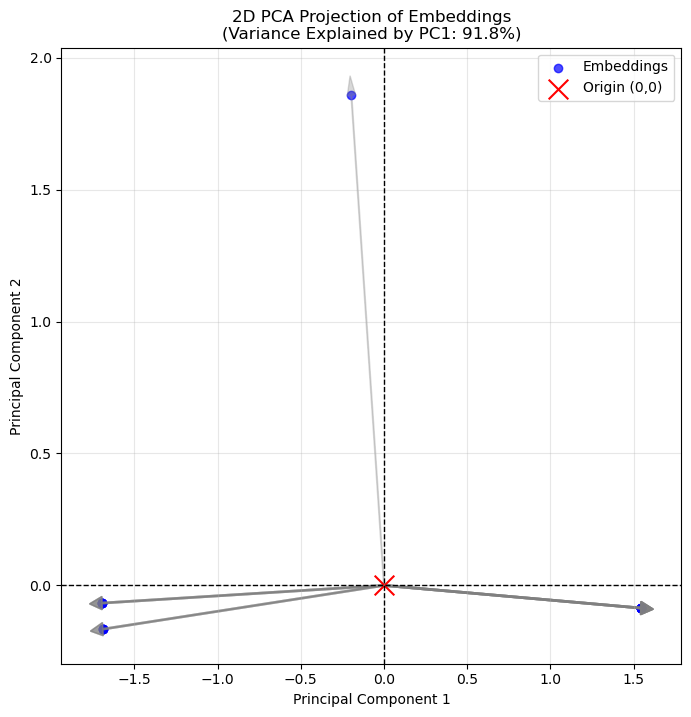

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# 2. Reduce the high-dimensional embeddings to 2D using PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(real_embeddings)

# Optional: Calculate average pairwise cosine similarity to prove the inflation
sim_matrix = cosine_similarity(real_embeddings)
# Get upper triangle excluding diagonal
avg_sim = np.mean(sim_matrix[np.triu_indices(sim_matrix.shape[0], k=1)])
print(f"Average Pairwise Cosine Similarity: {avg_sim:.4f}")

# 3. Plot the 2D representation
plt.figure(figsize=(8, 8))

# Plot the embedding points
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, color='blue', label='Embeddings')

# Draw arrows from the origin to each point to visualize the "vectors"
for i in range(len(embeddings_2d)):
    plt.arrow(0, 0, embeddings_2d[i, 0], embeddings_2d[i, 1], 
              color='gray', alpha=0.3, width=0.005, head_width=0.05)

# Mark the origin explicitly
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.scatter([0], [0], color='red', marker='x', s=200, label='Origin (0,0)')

plt.title(f"2D PCA Projection of Embeddings\n(Variance Explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, alpha=0.3)

# If the space is anisotropic, the points will cluster tightly in one direction
# rather than scattering around the red origin X.
plt.show()

1. Why the PCA doesn't look like a cone (The "Boilerplate" Effect)
In a typical dataset of 20 distinct sentences, we should see a scattered cloud of 20 separate dots. In our PCA plot, there are only about 4 distinct dots visible. Why? Because our data contains exact duplicates or they are actually using the same template for answering the questions. If we look at the dataframe snippet, the LLM often outputs exact boilerplate phrases like: "the case does not provide any information on...". If 8 out of 10 cases have the exact same reasoning text for Question 2, their embeddings will be mathematically identical. They plot exactly on top of each other, creating single heavy dots rather than a cloud.

However, the anisotropy is still there, if we look at the title of our plot: Variance Explained by PC1: 91.8%.
In a healthy, spherical 768-dimensional space, the first principal component (PC1) should explain maybe 5% to 10% of the variance. A PC1 of 91.8% means almost the entire embedding space is stretched out along a single 1-dimensional line. That extreme stretching is the mathematical signature of anisotropy, even if the "cloud" is missing due to duplicate texts.

2. Why the Heatmap isn't red (The Magic of Sentence Transformers)
The most important revelation is in our heatmap.

The Diagonal Blocks (Red = 1.0): Case Q2 vs Case Q2 is perfectly red. Again, this proves the texts for Q2 are nearly identical to each other across all cases. The Off-Diagonal Blocks (Peach = ~0.30): Case Q2 vs Case Q10 is a light peach color, which on our scale is roughly 0.30 to 0.40. Why didn't it score 0.85+ (usualy expectation of anisotropy). Because of the model we are using: paraphrase-multilingual-mpnet-base-v2. Sentence Transformers are explicitly trained using Contrastive Learning specifically to fix the anisotropy problem. The creators of mpnet already did the heavy lifting to ensure that dissimilar sentences (like Q2 timing vs Q10 objective evidence) are pushed apart into the 0.2 - 0.4 range.

3. What does this mean for our experiment?
Because we chosed a high-quality SentenceTransformer rather than a raw base model, our embeddings are already reasonably well-behaved. The model naturally understands that Q2 and Q10 are different concepts without needing massive mathematical correction.

# Reconciliation of results:

The result above looks like contradicting and may look like a classic data science paradox where two different mathematical tools seem to be telling conflicting stories.

The short answer lies in the mathematics: The PCA is measuring the shape of your specific 20-sentence dataset, while the Heatmap is measuring the angle from the origin (semantic similarity).

Here is the exact mathematical reconciliation of why both graphs are telling the truth, and why our model is still moderately performing well.

1. The "Barbell" Artifact (Why PC1 is 91.8%)
To understand the PCA plot, we have to look at how Principal Component Analysis actually works. Before PCA draws any lines, it finds the exact center (mean) of our data. Then, it draws its first axis (PC1) through the direction of maximum spread. Because our LLM output relies heavily on boilerplate templates, our specific sample of 20 sentences does not form a random cloud. Instead, it forms two very dense, tight clusters:

Cluster A: The identical Q2 sentences.

Cluster B: The two nearly identical Q10 sentences. Except for one which maybe due to Case 9 Question 10.

Geometrically, two points (or two tight clusters) define a 1-dimensional line. If you run PCA on a dataset that looks like a barbell, the line connecting the two weights must capture almost all the variance.

The 91.8% PC1 is an artifact of the boilerplate duplicates making our dataset look 1-dimensional. It is not proof that the Sentence Transformer's entire 768-dimensional space is a narrow anisotropic cone; it simply means our specific sample lacks structural diversity.

2. The Angle of Separation (Cosine Similarity Heatmap)
Cosine similarity operates on completely different geometry. It does not care about the local center of our dataset nor does it case about PC1 and PC2 line. It only cares about the absolute angle between vectors, drawn all the way from the origin (0, 0, 0...).

A cosine similarity of 1.0 means an angle of 0 degrees (exact duplicates).

A cosine similarity of 0.85 means an angle of roughly 31 degrees (highly anisotropic / clustered).

A cosine similarity of 0.30 to 0.40 (your peach color) equates to an angle of roughly 65 to 70 degrees (moderatley anisotoropic).

A 70-degree separation between vectors is moderatley healthy for contextual embeddings. It proves that the Sentence Transformer successfully recognizes that "Timing" (Q2) and "Objective Evidence" (Q10) are fundamentally different concepts and has pushed them far apart from the origin.

3. Rationale
There is no contradiction. The Heatmap proves the model is moderately good: It separates distinct concepts by wide angles (modest semantic anisotropy). The PCA proves our data sample is redundant: The heavy use of boilerplate templates collapses the variance of this specific batch into a single dimension (the line between Q2 and Q10).

# Side by Side Comparison of Anistropy and Istropy (after whitening) 

Generating raw embeddings...
Fitting PCA Whitener on the full corpus...
Applying whitening transformation...


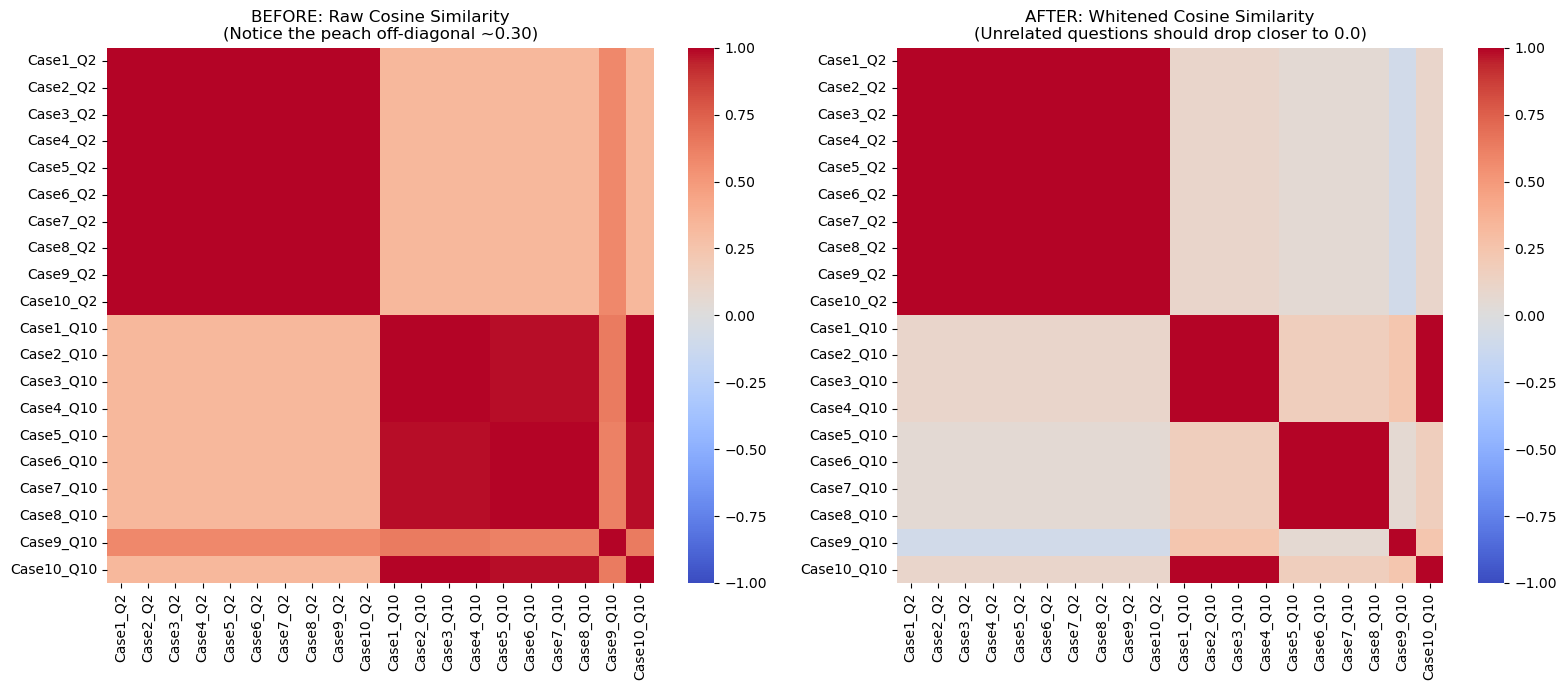

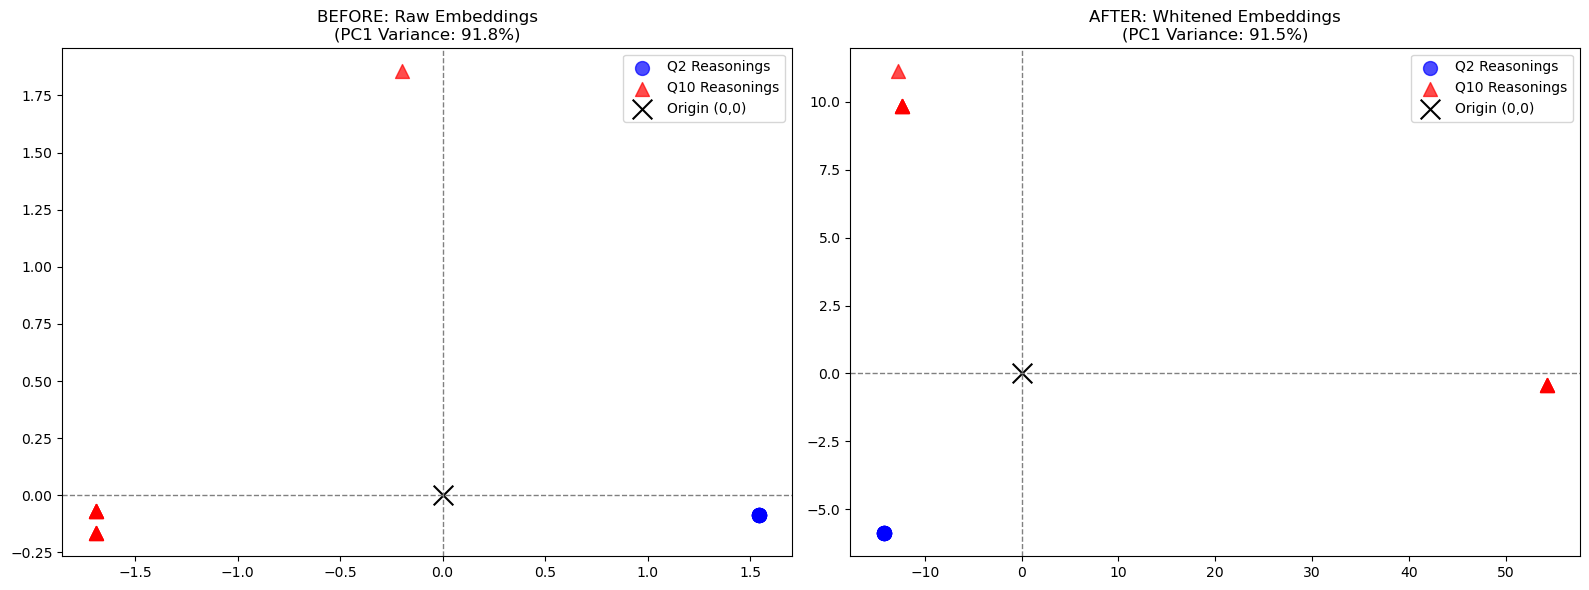

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# ============================================================
# 📊 Diagnostic: Compare Raw vs. Whitened Embeddings
# ============================================================

# 1. Extract texts
texts_q2 = df['Q2_Reasoning'].dropna().head(10).tolist()
texts_q10 = df['Q10_Reasoning'].dropna().head(10).tolist()
all_texts = texts_q2 + texts_q10
labels = [f"Case{i+1}_Q2" for i in range(10)] + [f"Case{i+1}_Q10" for i in range(10)]

# 2. Get Raw Embeddings
print("Generating raw embeddings...")
raw_embeddings = encoder.encode(all_texts)

# 3. Fit PCA Whitener on the larger medical corpus
print("Fitting PCA Whitener on the full corpus...")
corpus_texts = []
for q in range(2, 11):
    corpus_texts.extend(df[f'Q{q}_Reasoning'].dropna().tolist())
corpus_embeddings = encoder.encode(corpus_texts)

pca_whitener = PCA(whiten=True)
pca_whitener.fit(corpus_embeddings)

# 4. Get Whitened Embeddings
print("Applying whitening transformation...")
whitened_embeddings = pca_whitener.transform(raw_embeddings)

# ==========================================
# Plot 1: Side-by-Side Heatmaps
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Raw Heatmap
sns.heatmap(cosine_similarity(raw_embeddings), annot=False, cmap="coolwarm", vmin=-1, vmax=1,
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("BEFORE: Raw Cosine Similarity\n(Notice the peach off-diagonal ~0.30)")

# Whitened Heatmap
sns.heatmap(cosine_similarity(whitened_embeddings), annot=False, cmap="coolwarm", vmin=-1, vmax=1,
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("AFTER: Whitened Cosine Similarity\n(Unrelated questions should drop closer to 0.0)")

plt.tight_layout()
plt.show()

# ==========================================
# Plot 2: Side-by-Side 2D PCA Scatters
# ==========================================
# Reduce both dimensions for 2D visualization
pca_vis_raw = PCA(n_components=2)
raw_2d = pca_vis_raw.fit_transform(raw_embeddings)

pca_vis_whitened = PCA(n_components=2)
whit_2d = pca_vis_whitened.fit_transform(whitened_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw Scatter
axes[0].scatter(raw_2d[:10, 0], raw_2d[:10, 1], c='blue', label='Q2 Reasonings', s=100, alpha=0.7)
axes[0].scatter(raw_2d[10:, 0], raw_2d[10:, 1], c='red', label='Q10 Reasonings', s=100, alpha=0.7, marker='^')
axes[0].axhline(0, color='grey', linestyle='--', linewidth=1)
axes[0].axvline(0, color='grey', linestyle='--', linewidth=1)
axes[0].scatter([0], [0], c='black', marker='x', s=200, label='Origin (0,0)')
axes[0].set_title(f"BEFORE: Raw Embeddings\n(PC1 Variance: {pca_vis_raw.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].legend()

# Whitened Scatter
axes[1].scatter(whit_2d[:10, 0], whit_2d[:10, 1], c='blue', label='Q2 Reasonings', s=100, alpha=0.7)
axes[1].scatter(whit_2d[10:, 0], whit_2d[10:, 1], c='red', label='Q10 Reasonings', s=100, alpha=0.7, marker='^')
axes[1].axhline(0, color='grey', linestyle='--', linewidth=1)
axes[1].axvline(0, color='grey', linestyle='--', linewidth=1)
axes[1].scatter([0], [0], c='black', marker='x', s=200, label='Origin (0,0)')
axes[1].set_title(f"AFTER: Whitened Embeddings\n(PC1 Variance: {pca_vis_whitened.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].legend()

plt.tight_layout()
plt.show()